In [1]:
import tensorflow as tf
import os
import glob
import random
from common import feature_description,INPUT_SHAPE,OUTPUT_DIM_NOTES,filter_polyphony
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import common
from common import feature_description

subset='/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset_small'
input_filepaths=sorted(glob.glob(os.path.join(subset, '**', '*.tfrecord'), recursive=True))

# input_filepaths = ['/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00028.tfrecord',
#                    '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_63989.tfrecord',
#                    '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_63819.tfrecord']# 
random.shuffle(input_filepaths)
# input_filepaths=input_filepaths[:1000]
print("Number records found ",len(input_filepaths))

def parse_batch(serialized_batch):
    parsed = tf.io.parse_single_example(serialized_batch, feature_description)
    input_raw = tf.io.decode_raw(parsed["input"], tf.int8)
    label_raw = tf.io.decode_raw(parsed["output"], tf.int8)
    
    input_tensor = tf.reshape(input_raw, INPUT_SHAPE)
    input_tensor = tf.cast(input_tensor, tf.float32)
    input_tensor=input_tensor/127
    output_tensor = tf.cast(tf.reshape(label_raw, [OUTPUT_DIM_NOTES]), tf.float32)
    return input_tensor,output_tensor#input_raw,label_raw

def create_dataset(filepaths, batch_size=256):
    # Convert file list to a dataset of strings
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    
    # Read from multiple files in parallel
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
    
    # Batch the RAW serialized protos FIRST
    # dataset = dataset.batch(batch_size)
    

    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE,deterministic=True)
    return dataset.prefetch(tf.data.AUTOTUNE)



I0000 00:00:1774812640.159786   76381 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774812640.188678   76381 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774812641.289123   76381 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Number records found  2001


In [2]:
# dataset=create_dataset(input_filepaths)

# dataset=filter_polyphony(dataset,2,True)
# dataset_size=2001000#sum(1 for _ in dataset)

# print("Dataset size",dataset_size)

# from common import count_concurrent_notes_distribution,plot_histogram

# hist=count_concurrent_notes_distribution(dataset)
# plot_histogram(hist[:10],10)
# plot_histogram(hist)

In [3]:
# %% [markdown]
# # Dataset Browser

# %%
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import common
from common import feature_description

# # %%
# tfrecord_files = tf.io.gfile.glob("*.tfrecord")  # adjust path
# dataset = tf.data.TFRecordDataset(input_filepaths)

# def parse_example(example_proto):
#     parsed = tf.io.parse_single_example(example_proto, feature_description)
#     audio = tf.reshape(parsed['audio'], (148, 256))
#     label = parsed['label']  # vector
#     return audio, label

dataset =create_dataset(input_filepaths)
dataset=filter_polyphony(dataset,4,True)
# %% [markdown]
# ## Build label index

# %%
print("Indexing dataset by label...")
label_key_to_indices = {}  # tuple(label) -> [global_indices]
label_key_to_vector = {}   # tuple(label) -> np.array

for i, (audio, label) in enumerate(dataset):
    lv = label.numpy()
    key = tuple(lv)
    if key not in label_key_to_indices:
        label_key_to_indices[key] = []
        label_key_to_vector[key] = lv
    label_key_to_indices[key].append(i)
    if i % 100000 == 0:
        print(f"  scanned {i} examples...")

unique_keys = sorted(label_key_to_indices.keys())
print(f"Done. {len(unique_keys)} unique labels, {i+1} total examples.")

# %% [markdown]
# ## Interactive Browser

# %%
label_slider = widgets.IntSlider(
    value=0, min=0, max=len(unique_keys) - 1, step=1,
    description='Label #:',
    continuous_update=False
)

instance_slider = widgets.IntSlider(
    value=0, min=0, max=0, step=1,
    description='Instance:',
    continuous_update=False
)

def get_by_index(dataset, idx):
    for i,(audio,label) in enumerate(dataset):
        if i==idx:
            return audio,label
    return None


# Buttons for label slider
label_left = widgets.Button(description='◀', layout=widgets.Layout(width='40px'))
label_right = widgets.Button(description='▶', layout=widgets.Layout(width='40px'))

# Buttons for instance slider
inst_left = widgets.Button(description='◀', layout=widgets.Layout(width='40px'))
inst_right = widgets.Button(description='▶', layout=widgets.Layout(width='40px'))

def label_left_click(b):
    if label_slider.value > label_slider.min:
        label_slider.value -= 1

def label_right_click(b):
    if label_slider.value < label_slider.max:
        label_slider.value += 1

def inst_left_click(b):
    if instance_slider.value > instance_slider.min:
        instance_slider.value -= 1

def inst_right_click(b):
    if instance_slider.value < instance_slider.max:
        instance_slider.value += 1

label_left.on_click(label_left_click)
label_right.on_click(label_right_click)
inst_left.on_click(inst_left_click)
inst_right.on_click(inst_right_click)

info_label = widgets.Label(value="")
label_display = widgets.Label(value="")
output = widgets.Output()

def lowest_active(key):
    positions = [i for i, v in enumerate(key) if v == 1]
    return positions[0] if positions else float('inf')

unique_keys = sorted(label_key_to_indices.keys(), key=lowest_active)

# Add a global dict to store vmin/vmax per label
label_vrange = {}

label_overview = {}

def on_label_change(change):
    key = unique_keys[label_slider.value]
    vec = label_key_to_vector[key]
    n = len(label_key_to_indices[key])
    instance_slider.max = n - 1
    instance_slider.value = 0
    info_label.value = f"{n} examples"
    active_positions = list(np.where(vec == 1)[0])
    label_display.value = f"Active positions: {active_positions} (lowest: {active_positions[0] if active_positions else 'none'})"

    indices = label_key_to_indices[key]
    vmin, vmax = float('inf'), float('-inf')
    overview_cols = []
    for idx in indices:
        example = dataset.skip(idx).take(1)
        audio, _ = next(iter(example))
        a = audio.numpy()
        vmin = min(vmin, a.min())
        vmax = max(vmax, a.max())
        overview_cols.append(a.max(axis=1))

    label_vrange[label_slider.value] = (vmin, vmax)
    label_overview[label_slider.value] = np.stack(overview_cols, axis=1)

    show_image(None)

def show_image(change):
    key = unique_keys[label_slider.value]
    global_idx = label_key_to_indices[key][instance_slider.value]

    example = dataset.skip(global_idx).take(1)
    audio, lbl = next(iter(example))
    audio_np = audio.numpy()

    vmin, vmax = label_vrange.get(label_slider.value, (audio_np.min(), audio_np.max()))
    overview = label_overview.get(label_slider.value)

    with output:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [3, 2]})

        ax = axes[0]
        im = ax.imshow(audio_np, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
        ax.set_title(f"Label #{label_slider.value} | Inst {instance_slider.value}/{instance_slider.max} | idx: {global_idx}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Frequency")
        plt.colorbar(im, ax=ax)

        ax2 = axes[1]
        im2 = ax2.imshow(overview, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
        ax2.axvline(x=instance_slider.value, color='cyan', linewidth=2, linestyle='--')
        ax2.set_title(f"All {overview.shape[1]} instances (max over time)")
        ax2.set_xlabel("Instance")
        ax2.set_ylabel("Frequency")
        plt.colorbar(im2, ax=ax2)

        plt.tight_layout()
        plt.show()



label_slider.observe(on_label_change, names='value')
instance_slider.observe(show_image, names='value')

display(widgets.VBox([
    widgets.HBox([label_left, label_slider, label_right]),
    label_display,
    widgets.HBox([inst_left, instance_slider, inst_right, info_label]),
    output
]))

on_label_change({'new': 0})


W0000 00:00:1774812504.473671   75256 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774812504.485203   75256 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774812504.564527   75256 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1266 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a


TypeError: The `filenames` argument must contain `tf.string` elements. Got `tf.float32` elements.

W0000 00:00:1774599324.689547   28796 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1774599324.697273   28796 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1774599324.773204   28796 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13737 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a
I0000 00:00:1774599324.948853   28931 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


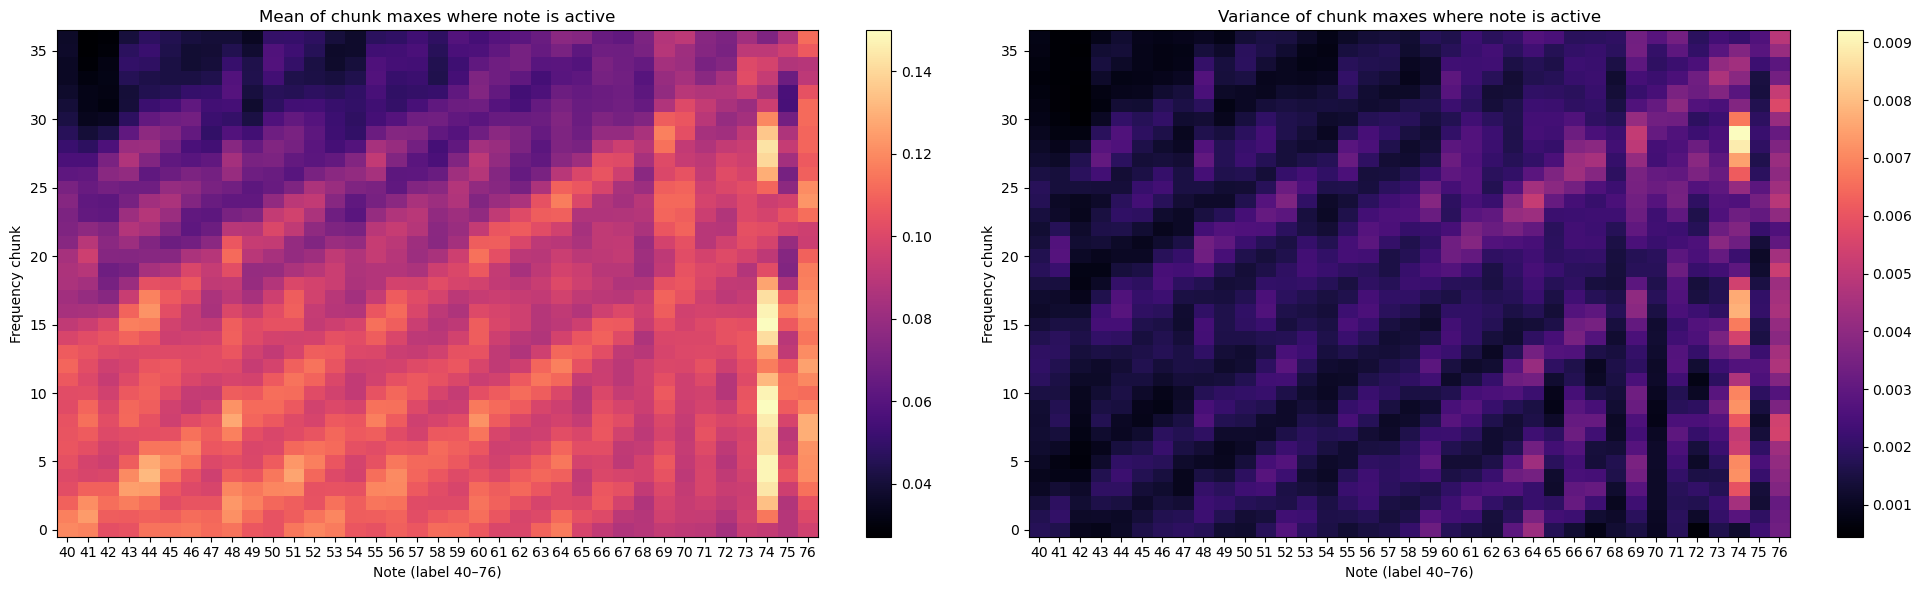

In [ ]:
import numpy as np
dataset =create_dataset(input_filepaths)
dataset=filter_polyphony(dataset,3,True)
# For each note (label 40..76), collect chunk maxes across all examples where that note is active
note_chunks = {i: [] for i in range(37)}  # note_chunks[i] -> list of (37,4) max vectors

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)  # (148,)
    label_sub = label.numpy()[40:77]       # (37,)
    chunks = audio_max.reshape(37, 4).max(axis=1)      # (37, 4)
    
    active = np.where(label_sub == 1)[0]
    for note in active:
        note_chunks[note].append(chunks)   # full (37,4) per example

# Build variance image: for each active note, variance of each chunk's max across examples
# Result: (37_chunks * 4_harmonics, 37_notes) = (148, 37)
var_image = np.zeros((37, 37))
mean_image= np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)  # (N, 37, 4)
        stacked_flat = stacked.reshape(len(note_chunks[note]), 37)  # (N, 148)
        var_image[:, note] = np.var(stacked_flat, axis=0)
        mean_image[:, note] = np.mean(stacked_flat, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

im1 = ax1.imshow(mean_image, aspect='auto', origin='lower', cmap='magma')
ax1.set_xlabel("Note (label 40–76)")
ax1.set_ylabel("Frequency chunk")
ax1.set_xticks(range(37))
ax1.set_xticklabels(range(40, 77))
ax1.set_title("Mean of chunk maxes where note is active")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(var_image, aspect='auto', origin='lower', cmap='magma')
ax2.set_xlabel("Note (label 40–76)")
ax2.set_ylabel("Frequency chunk")
ax2.set_xticks(range(37))
ax2.set_xticklabels(range(40, 77))
ax2.set_title("Variance of chunk maxes where note is active")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()



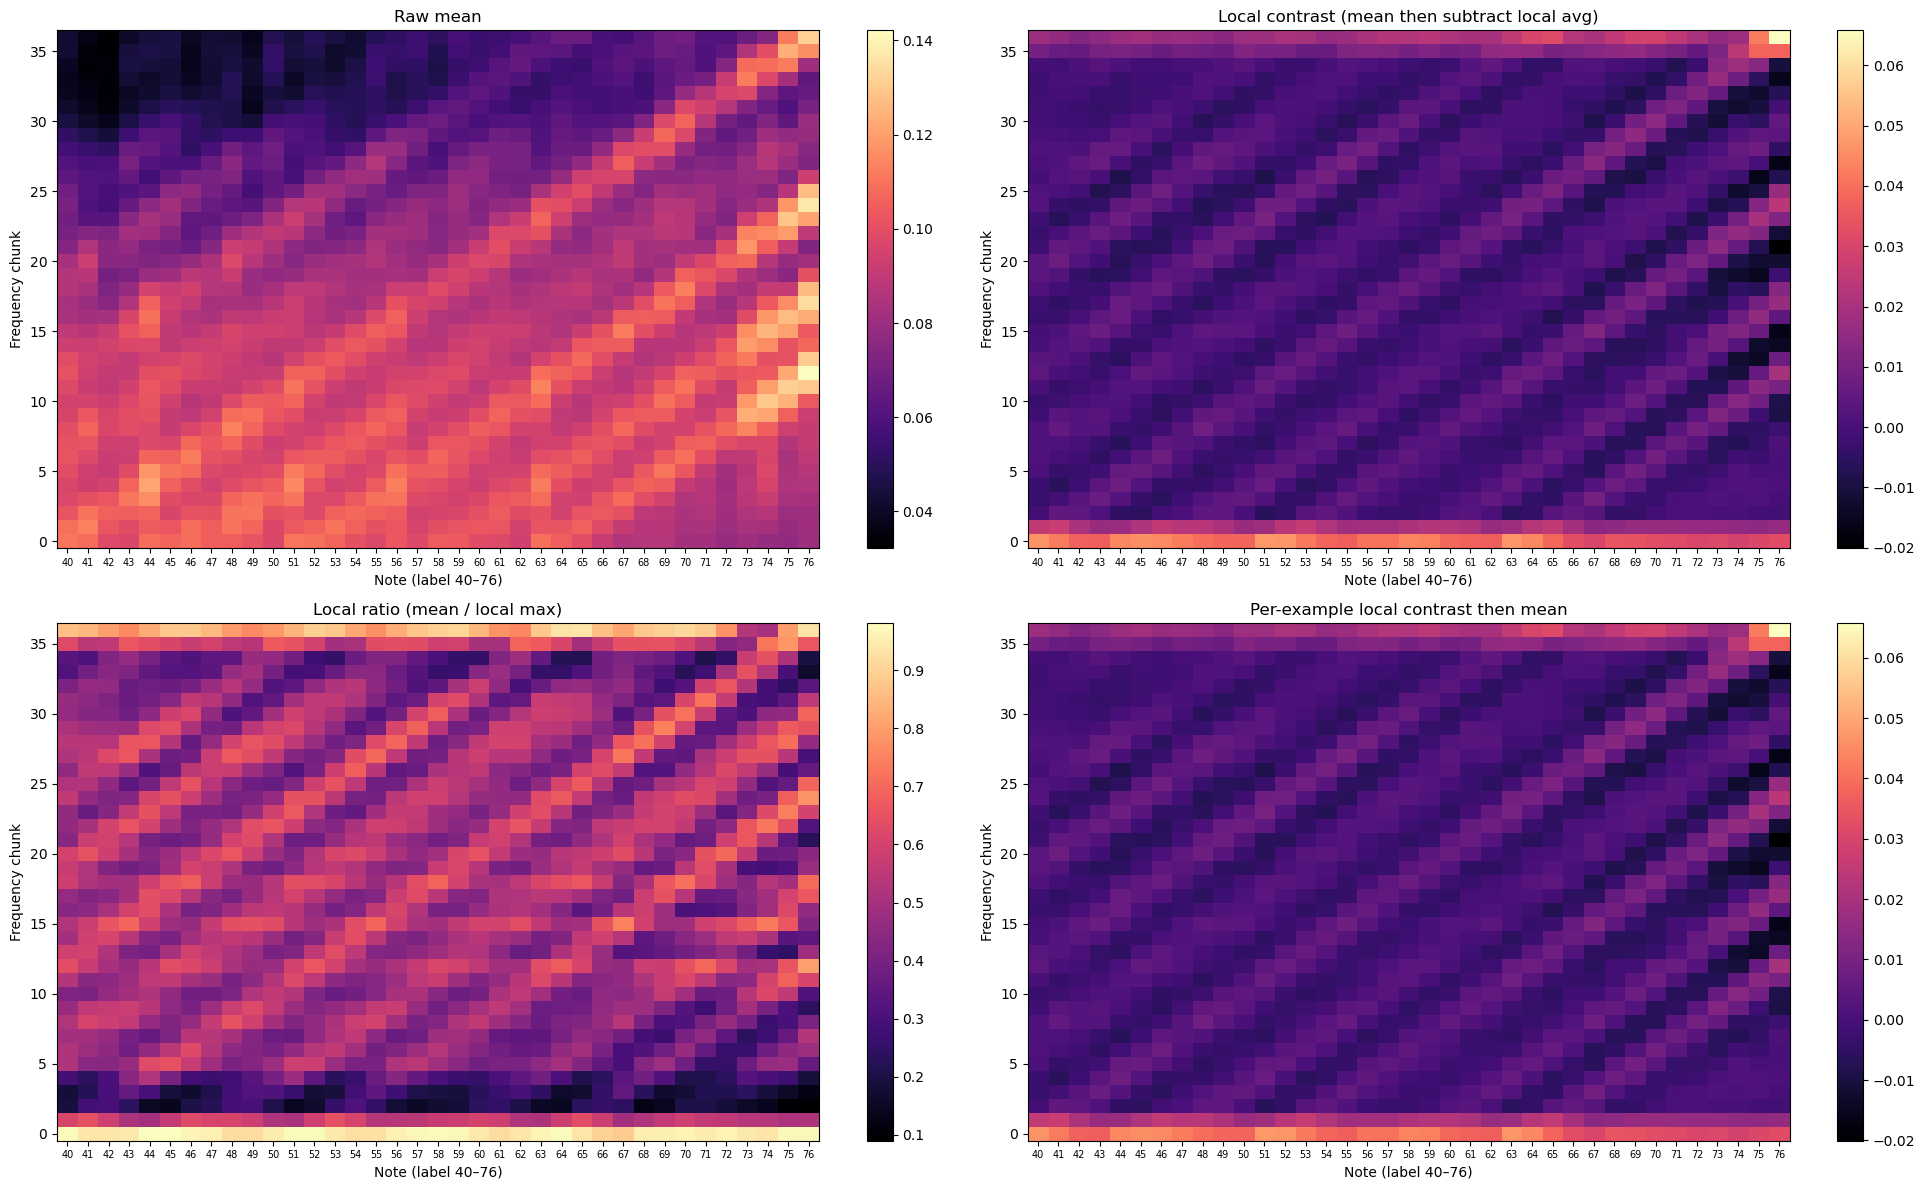

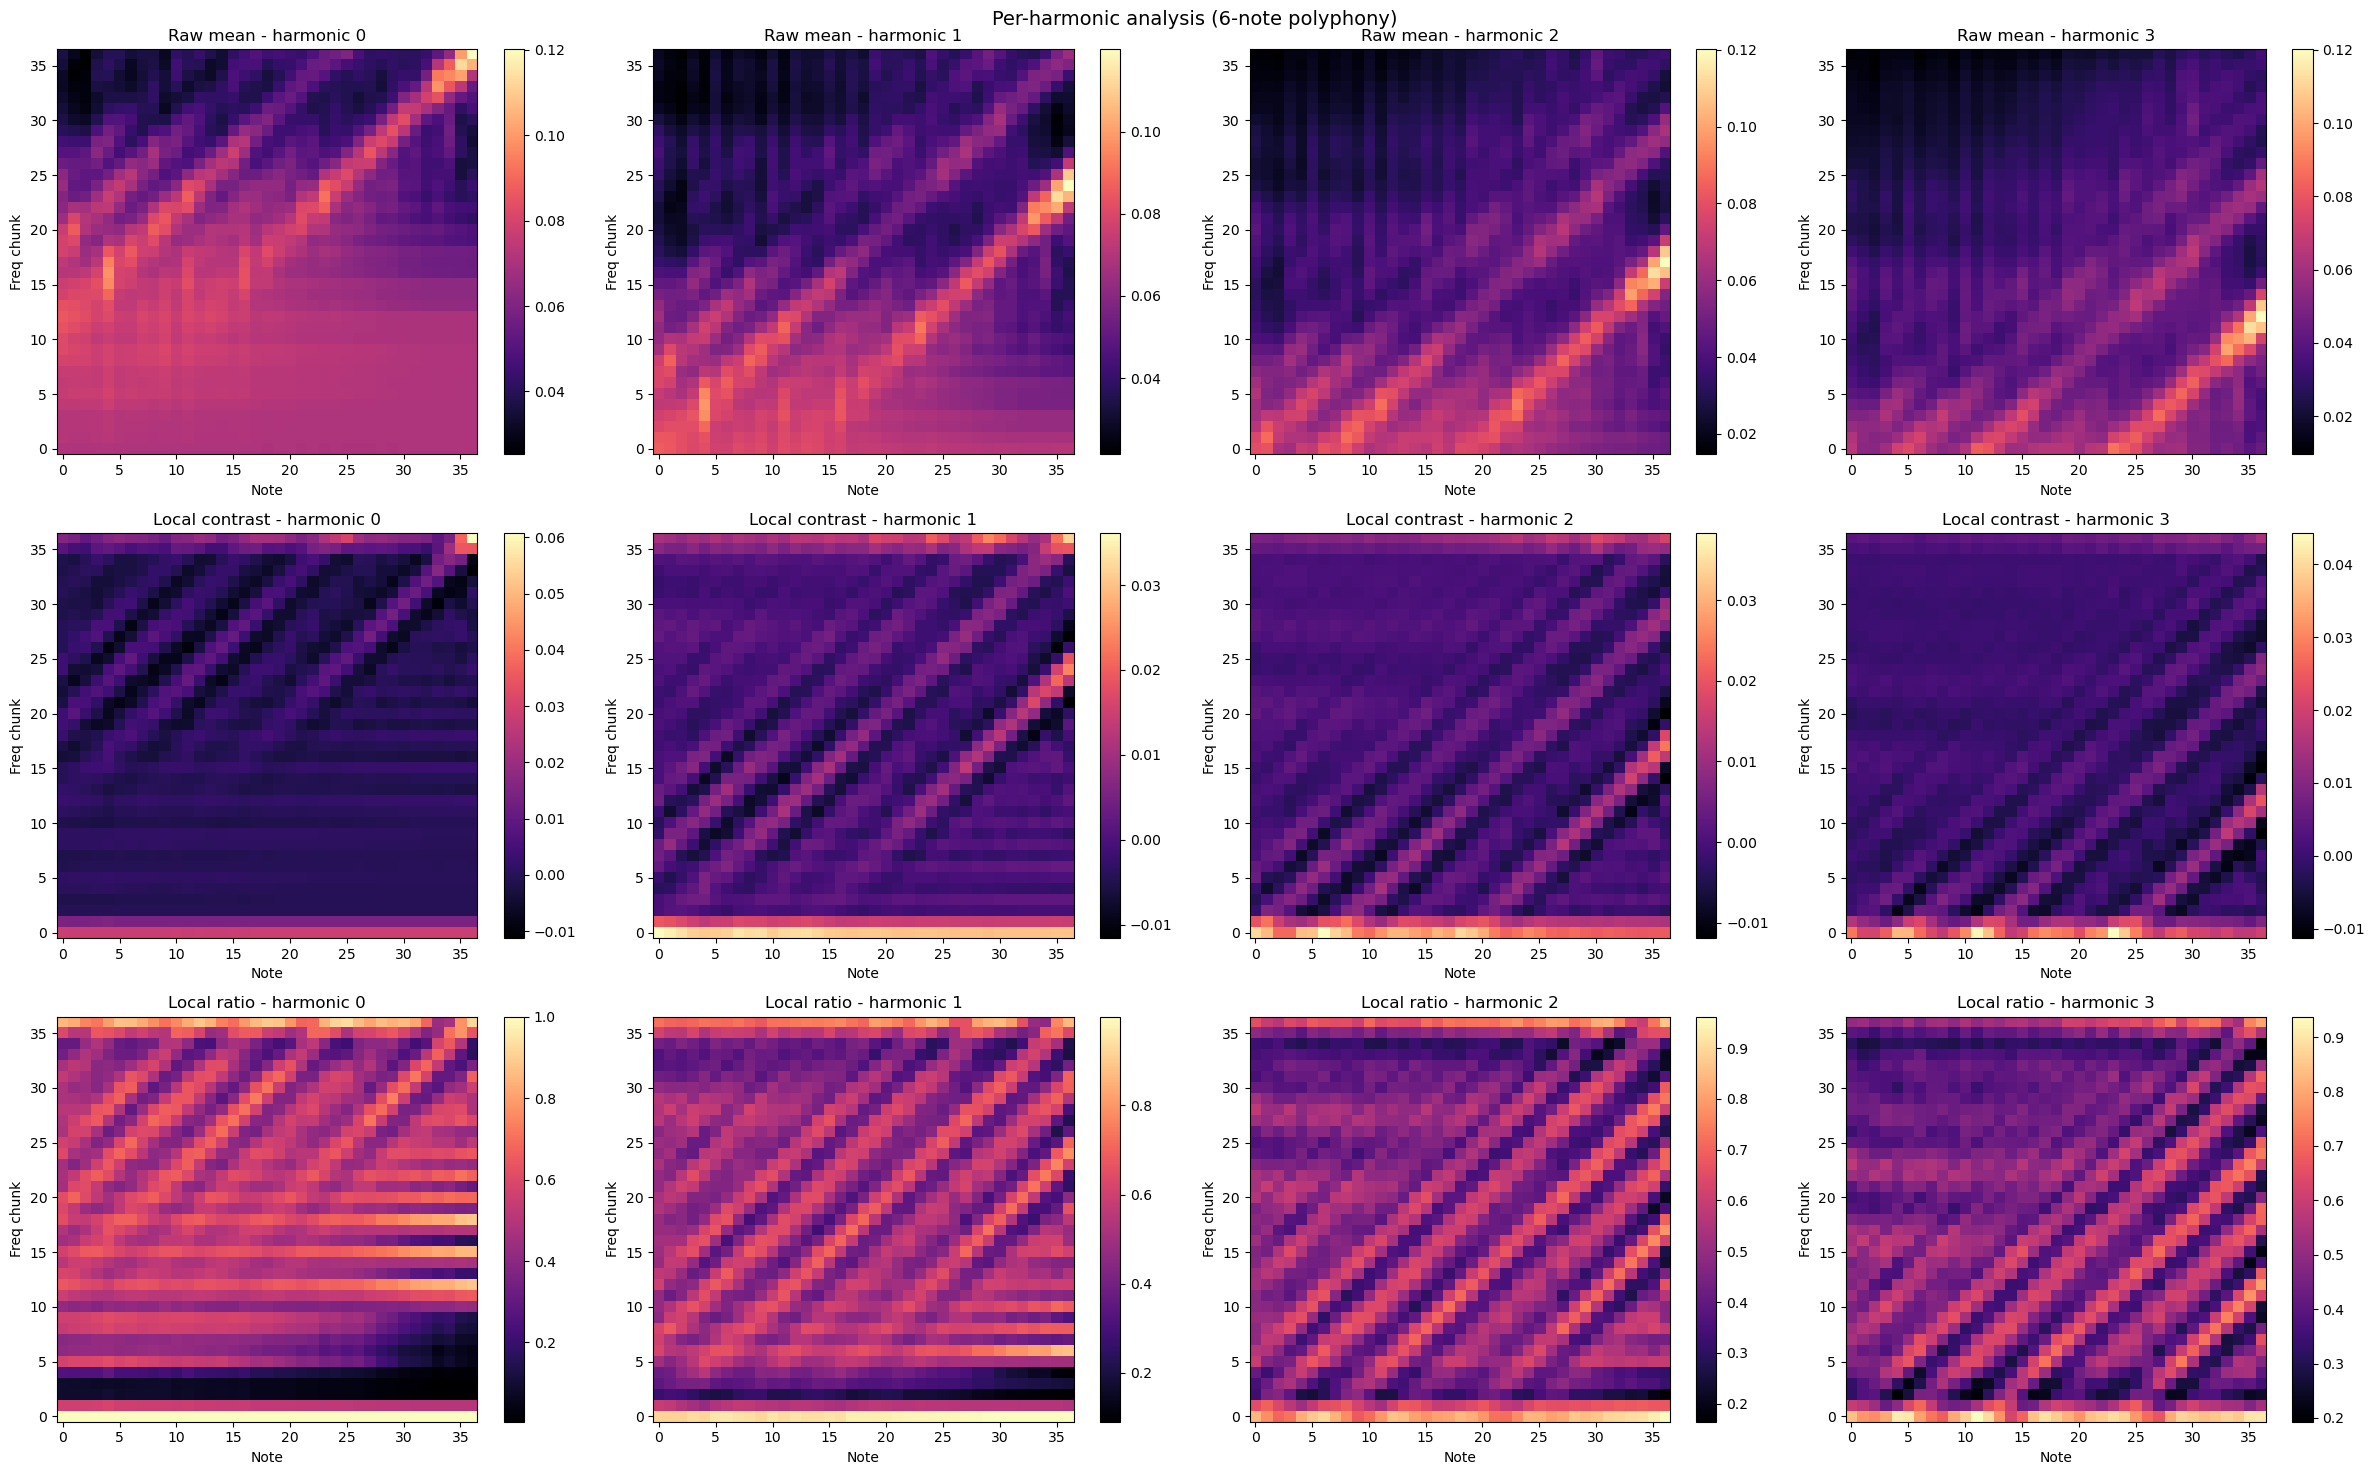

In [4]:
import numpy as np
from scipy.ndimage import maximum_filter1d,minimum_filter1d

dataset = create_dataset(input_filepaths)
dataset = filter_polyphony(dataset, 6, False)

note_chunks = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4).max(axis=1)

    active = np.where(label_sub == 1)[0]
    for note in active:
        note_chunks[note].append(chunks)

# Raw mean
mean_image = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        mean_image[:, note] = np.mean(stacked, axis=0)

# Local contrast
local_contrast_image = np.zeros((37, 37))
for note in range(37):
    col = mean_image[:, note]
    kernel = np.ones(5) / 5
    local_mean = np.convolve(col, kernel, mode='same')
    local_contrast_image[:, note] = col - local_mean

# Local ratio
local_ratio_image = np.zeros((37, 37))
# for note in range(37):
#     col = mean_image[:, note]
#     local_max = maximum_filter1d(col, size=7)
#     local_max = np.maximum(local_max, 1e-8)
#     local_ratio_image[:, note] = col / local_max

# Per-example local contrast
mean_contrast_per_example = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            local_mean = np.convolve(stacked[i], kernel, mode='same')
            contrasted[i] = stacked[i] - local_mean
            local_max=maximum_filter1d(contrasted[i],7)
            local_min=minimum_filter1d(contrasted[i],7)
            local_diff = np.maximum(local_max-local_min, 1e-8)
            ratio[i]=contrasted[i]/local_diff-local_min/local_diff
            
        mean_contrast_per_example[:, note] = np.mean(contrasted, axis=0)
        local_ratio_image[:,note]=np.mean(ratio,axis=0)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for ax, img, title in zip(
    axes.flat,
    [mean_image, local_contrast_image, local_ratio_image, mean_contrast_per_example],
    ["Raw mean", "Local contrast (mean then subtract local avg)",
     "Local ratio (mean / local max)", "Per-example local contrast then mean"]
):
    im = ax.imshow(img, aspect='auto', origin='lower', cmap='magma')
    ax.set_xlabel("Note (label 40–76)")
    ax.set_ylabel("Frequency chunk")
    ax.set_xticks(range(37))
    ax.set_xticklabels(range(40, 77), fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Full 4-harmonic resolution
note_chunks_full = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4)

    active = np.where(label_sub == 1)[0]
    for note in active:
        note_chunks_full[note].append(chunks)

mean_full = np.zeros((37, 4, 37))
contrast_full = np.zeros((37, 4, 37))
ratio_full = np.zeros((37, 4, 37))

for note in range(37):
    if len(note_chunks_full[note]) > 1:
        stacked = np.stack(note_chunks_full[note], axis=0)  # (N, 37, 4)
        mean_full[:, :, note] = np.mean(stacked, axis=0)

        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            for h in range(4):
                local_mean = np.convolve(stacked[i, :, h], kernel, mode='same')
                contrasted[i, :, h] = stacked[i, :, h] - local_mean
                local_max = maximum_filter1d(contrasted[i, :, h], 7)
                local_min = minimum_filter1d(contrasted[i, :, h], 7)
                local_diff = np.maximum(local_max - local_min, 1e-8)
                ratio[i, :, h] = contrasted[i, :, h] / local_diff - local_min / local_diff

                

        contrast_full[:, :, note] = np.mean(contrasted, axis=0)
        ratio_full[:,:,note]=np.mean(ratio,axis=0)

    # Local ratio on the mean
    # for h in range(4):
    #     col = mean_full[:, h, note]
    #     local_max = maximum_filter1d(col, size=7)
    #     local_max = np.maximum(local_max, 1e-8)
    #     ratio_full[:, h, note] = col / local_max

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
for h in range(4):
    im1 = axes[0, h].imshow(mean_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[0, h].set_title(f"Raw mean - harmonic {h}")
    axes[0, h].set_xlabel("Note")
    axes[0, h].set_ylabel("Freq chunk")
    plt.colorbar(im1, ax=axes[0, h])

    im2 = axes[1, h].imshow(contrast_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[1, h].set_title(f"Local contrast - harmonic {h}")
    axes[1, h].set_xlabel("Note")
    axes[1, h].set_ylabel("Freq chunk")
    plt.colorbar(im2, ax=axes[1, h])

    im3 = axes[2, h].imshow(ratio_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[2, h].set_title(f"Local ratio - harmonic {h}")
    axes[2, h].set_xlabel("Note")
    axes[2, h].set_ylabel("Freq chunk")
    plt.colorbar(im3, ax=axes[2, h])

plt.suptitle("Per-harmonic analysis (6-note polyphony)", fontsize=14)
plt.tight_layout()
plt.show()


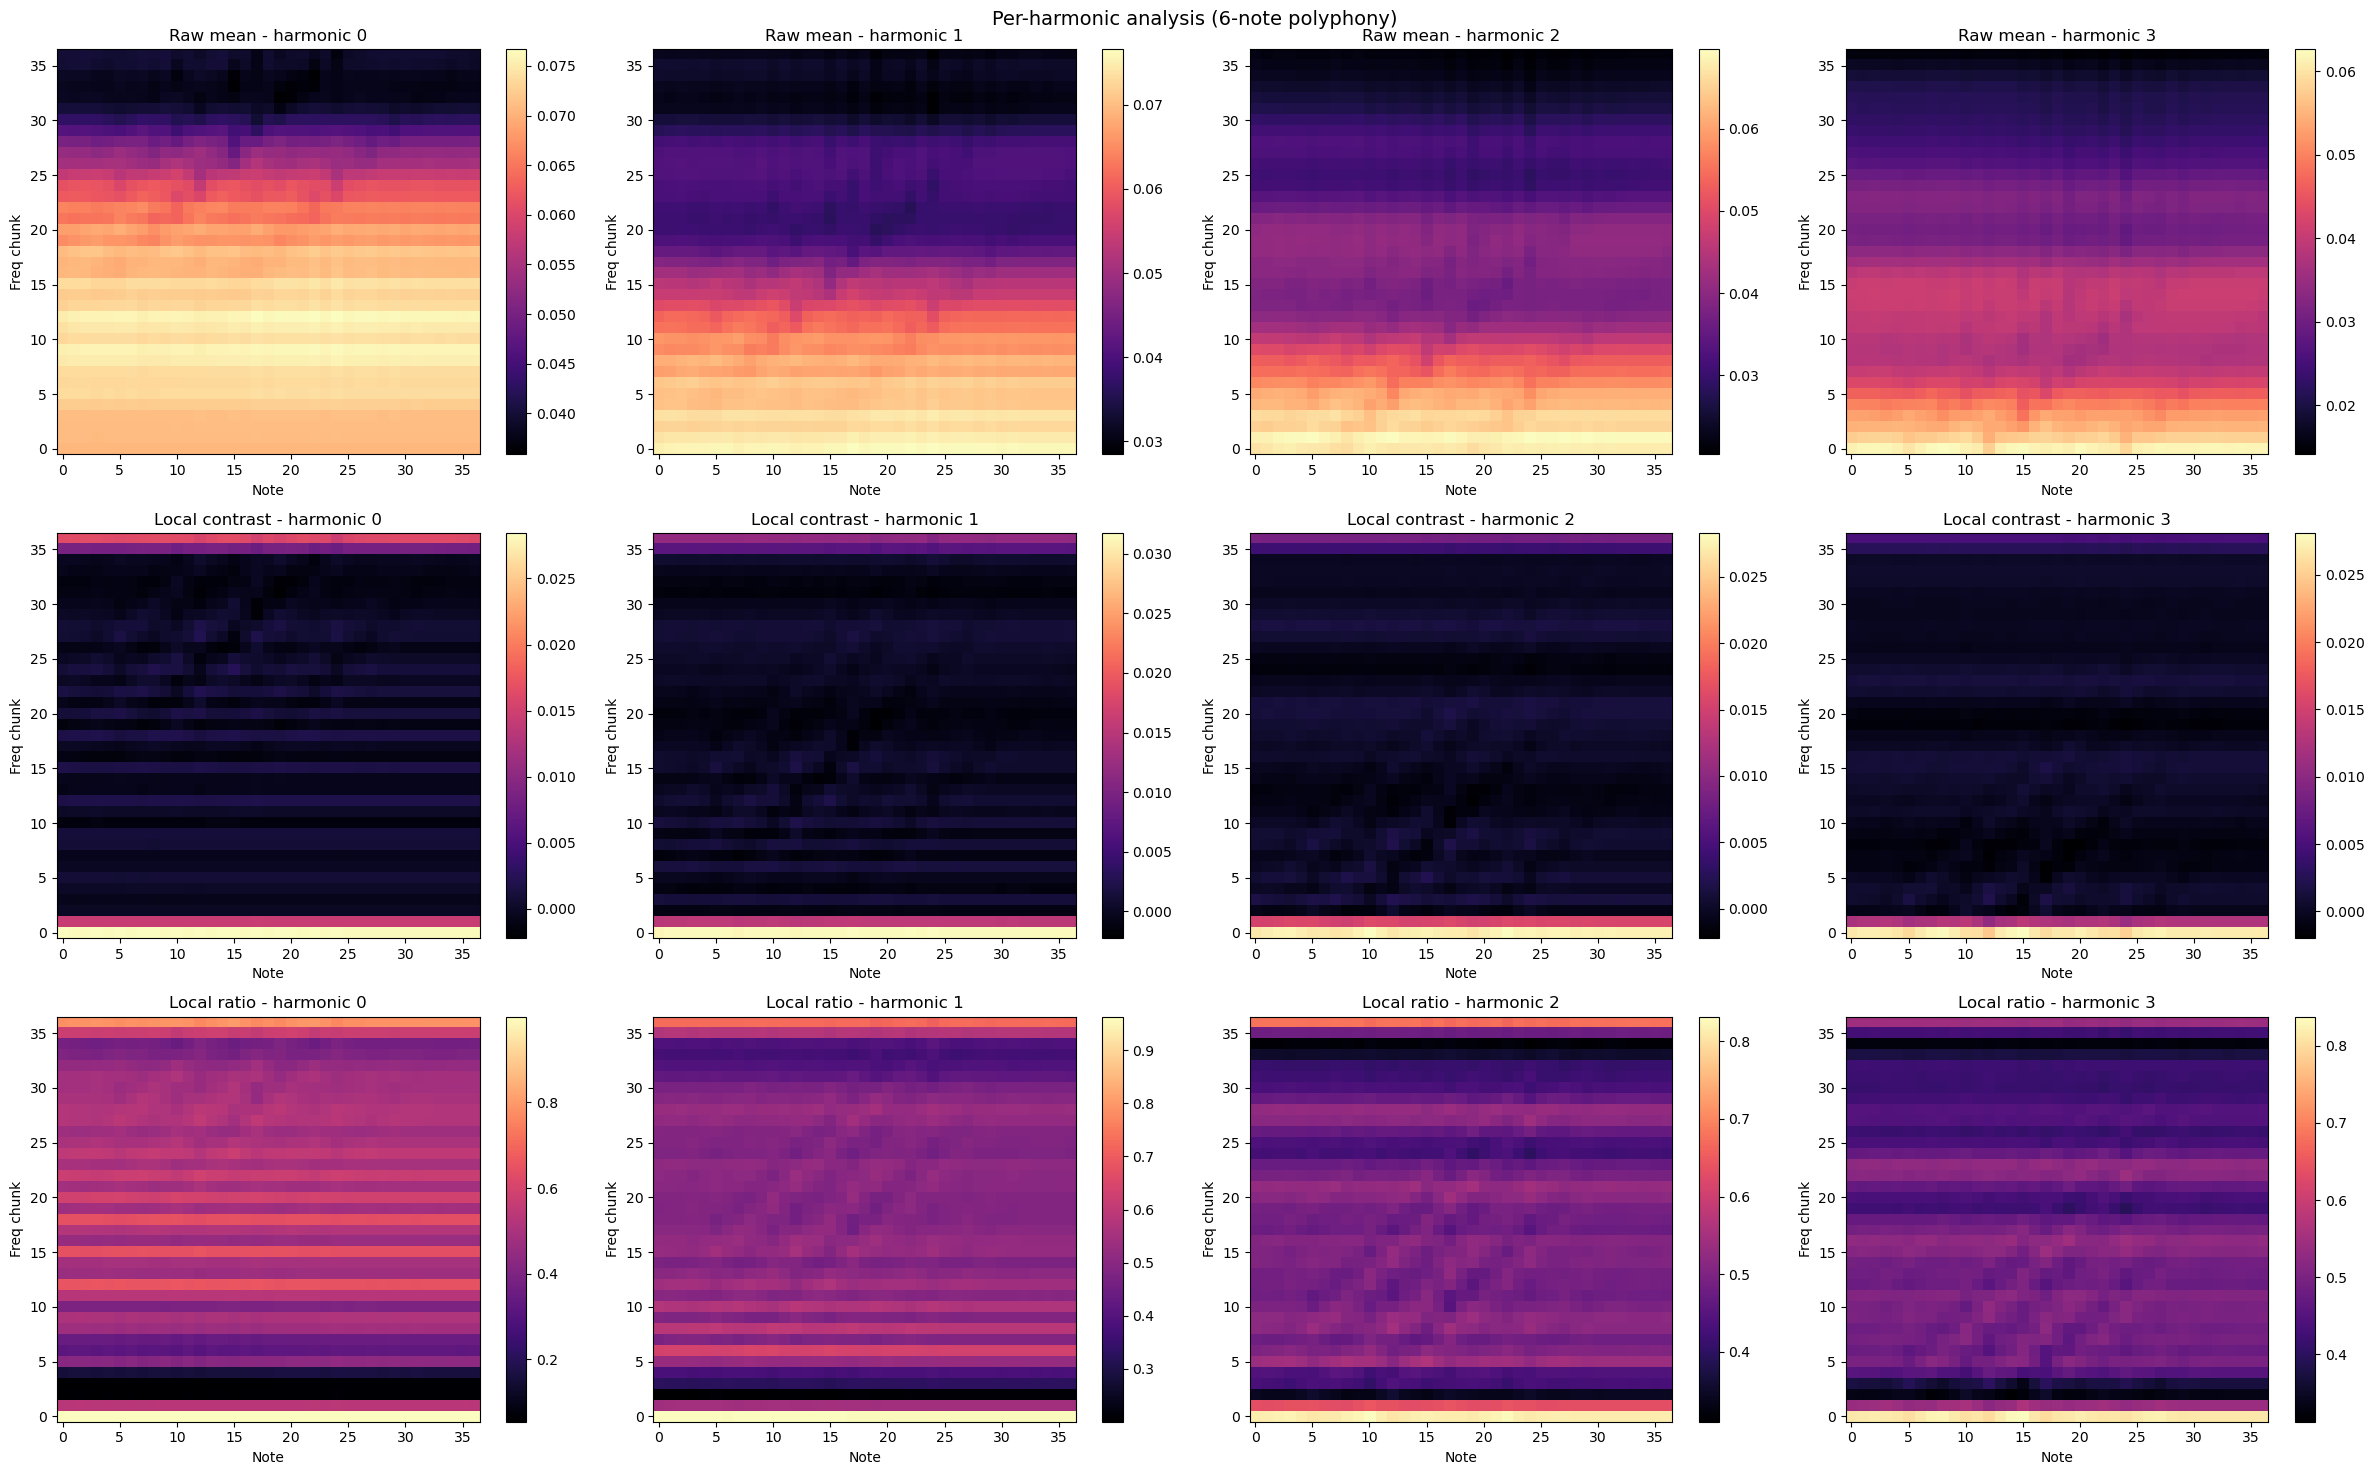

In [ ]:
# Non active notes
import numpy as np
from scipy.ndimage import maximum_filter1d,minimum_filter1d

dataset = create_dataset(input_filepaths)
dataset = filter_polyphony(dataset, 6, False)

note_chunks = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4).max(axis=1)

    inactive = np.where(label_sub == 0)[0]
    for note in inactive:
        note_chunks[note].append(chunks)

# Raw mean
mean_image = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        mean_image[:, note] = np.mean(stacked, axis=0)

# Local contrast
local_contrast_image = np.zeros((37, 37))
for note in range(37):
    col = mean_image[:, note]
    kernel = np.ones(5) / 5
    local_mean = np.convolve(col, kernel, mode='same')
    local_contrast_image[:, note] = col - local_mean

# Local ratio
local_ratio_image = np.zeros((37, 37))
# for note in range(37):
#     col = mean_image[:, note]
#     local_max = maximum_filter1d(col, size=7)
#     local_max = np.maximum(local_max, 1e-8)
#     local_ratio_image[:, note] = col / local_max

# Per-example local contrast
mean_contrast_per_example = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            local_mean = np.convolve(stacked[i], kernel, mode='same')
            contrasted[i] = stacked[i] - local_mean
            local_max=maximum_filter1d(contrasted[i],7)
            local_min=minimum_filter1d(contrasted[i],7)
            local_diff = np.maximum(local_max-local_min, 1e-8)
            ratio[i]=contrasted[i]/local_diff-local_min/local_diff
            
        mean_contrast_per_example[:, note] = np.mean(contrasted, axis=0)
        local_ratio_image[:,note]=np.mean(ratio,axis=0)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for ax, img, title in zip(
    axes.flat,
    [mean_image, local_contrast_image, local_ratio_image, mean_contrast_per_example],
    ["Raw mean", "Local contrast (mean then subtract local avg)",
     "Local ratio (mean / local max)", "Per-example local contrast then mean"]
):
    im = ax.imshow(img, aspect='auto', origin='lower', cmap='magma')
    ax.set_xlabel("Note (label 40–76)")
    ax.set_ylabel("Frequency chunk")
    ax.set_xticks(range(37))
    ax.set_xticklabels(range(40, 77), fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Full 4-harmonic resolution
note_chunks_full = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4)

    inactive = np.where(label_sub == 0)[0]
    for note in inactive:
        note_chunks_full[note].append(chunks)

mean_full = np.zeros((37, 4, 37))
contrast_full = np.zeros((37, 4, 37))
ratio_full = np.zeros((37, 4, 37))

for note in range(37):
    if len(note_chunks_full[note]) > 1:
        stacked = np.stack(note_chunks_full[note], axis=0)  # (N, 37, 4)
        mean_full[:, :, note] = np.mean(stacked, axis=0)

        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            for h in range(4):
                local_mean = np.convolve(stacked[i, :, h], kernel, mode='same')
                contrasted[i, :, h] = stacked[i, :, h] - local_mean
                local_max = maximum_filter1d(contrasted[i, :, h], 7)
                local_min = minimum_filter1d(contrasted[i, :, h], 7)
                local_diff = np.maximum(local_max - local_min, 1e-8)
                ratio[i, :, h] = contrasted[i, :, h] / local_diff - local_min / local_diff

                

        contrast_full[:, :, note] = np.mean(contrasted, axis=0)
        ratio_full[:,:,note]=np.mean(ratio,axis=0)

    # Local ratio on the mean
    # for h in range(4):
    #     col = mean_full[:, h, note]
    #     local_max = maximum_filter1d(col, size=7)
    #     local_max = np.maximum(local_max, 1e-8)
    #     ratio_full[:, h, note] = col / local_max

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
for h in range(4):
    im1 = axes[0, h].imshow(mean_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[0, h].set_title(f"Raw mean - harmonic {h}")
    axes[0, h].set_xlabel("Note")
    axes[0, h].set_ylabel("Freq chunk")
    plt.colorbar(im1, ax=axes[0, h])

    im2 = axes[1, h].imshow(contrast_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[1, h].set_title(f"Local contrast - harmonic {h}")
    axes[1, h].set_xlabel("Note")
    axes[1, h].set_ylabel("Freq chunk")
    plt.colorbar(im2, ax=axes[1, h])

    im3 = axes[2, h].imshow(ratio_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[2, h].set_title(f"Local ratio - harmonic {h}")
    axes[2, h].set_xlabel("Note")
    axes[2, h].set_ylabel("Freq chunk")
    plt.colorbar(im3, ax=axes[2, h])

plt.suptitle("Per-harmonic analysis (6-note polyphony)", fontsize=14)
plt.tight_layout()
plt.show()
